In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

**Data Acquisition, exploration, and preprocessing** \
Abbiamo un dataset per ogni stazione. \
Consideriamo 5 stazioni: Aotizhongzin, Changping, Dingling, Dongsi e Guanyuan. 


In [7]:
PATH_Aotizhongxin = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
PATH_Changping = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv"
PATH_Dingling = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv"
PATH_Dongsi = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv"
PATH_Guanyuan = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv"

df_aotizhongzin = pd.read_csv(PATH_Aotizhongxin)
df_changping = pd.read_csv(PATH_Changping)
df_dingling = pd.read_csv(PATH_Dingling)
df_dongsi = pd.read_csv(PATH_Dongsi)
df_guanyuan = pd.read_csv(PATH_Guanyuan)

In [8]:
df_aotizhongzin

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4,Aotizhongxin
35060,35061,2017,2,28,20,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Aotizhongxin
35061,35062,2017,2,28,21,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1,Aotizhongxin
35062,35063,2017,2,28,22,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Aotizhongxin


In [9]:
df_changping

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping
35060,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping
35061,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping
35062,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping


In [10]:
df_dingling

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling
35060,35061,2017,2,28,20,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1,Dingling
35061,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling
35062,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling


In [11]:
df_dongsi

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
35060,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
35061,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
35062,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


In [12]:
df_guanyuan

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
35060,35061,2017,2,28,20,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
35061,35062,2017,2,28,21,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
35062,35063,2017,2,28,22,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


In [13]:
# Column description obtained from the source of the dataset
column_descriptions = [
    {"Column Name": "No", "Description": "Row number"},
    {"Column Name": "year", "Description": "Year in which data in this row was acquired"}, 
    {"Column Name": "month", "Description": "Month in which data in this row was acquired"}, 
    {"Column Name": "day", "Description": "Day in which data in this row was acquired"}, 
    {"Column Name": "hour", "Description": "Hour in which data in this row was acquired"}, 
    {"Column Name": "PM2.5", "Description": "PM2.5 concentration (ug/m^3)"}, 
    {"Column Name": "PM10", "Description": "PM10 concentration (ug/m^3)"}, 
    {"Column Name": "SO2", "Description": "SO2 concentration (ug/m^3)"}, 
    {"Column Name": "NO2", "Description": "NO2 concentration (ug/m^3)"}, 
    {"Column Name": "CO", "Description": "CO concentration (ug/m^3)"}, 
    {"Column Name": "O3", "Description": "O3 concentration (ug/m^3)"}, 
    {"Column Name": "TEMP", "Description": "Temperature (degree Celsius)"}, 
    {"Column Name": "PRES", "Description": "Pressure (hPa)"}, 
    {"Column Name": "DEWP", "Description": "Dew point temperature (degree Celsius)"}, 
    {"Column Name": "RAIN", "Description": "Precipitation (mm)"}, 
    {"Column Name": "wd", "Description": "Wind direction"}, 
    {"Column Name": "WSPM", "Description": "Wind speed (m/s)"}, 
    {"Column Name": "station", "Description": "Name of the air-quality monitoring site"}
]

df_description = pd.DataFrame(column_descriptions)

df_description


,Column Name,Description
0,No,Row number
1,year,Year in which data in this row was acquired
2,month,Month in which data in this row was acquired
3,day,Day in which data in this row was acquired
4,hour,Hour in which data in this row was acquired
5,PM2.5,PM2.5 concentration (ug/m^3)
6,PM10,PM10 concentration (ug/m^3)
7,SO2,SO2 concentration (ug/m^3)
8,NO2,NO2 concentration (ug/m^3)
9,CO,CO concentration (ug/m^3)


Importiamo i dataset e aggiustiamo la data: da year, month, day, hour otteniamo un timestamp ordinabile. Inoltre, teniamo solo le features che ci interessano (rimuoviamo anche il numero di riga e il nome della stazione, cioè No e station)

In [14]:
PATH_Aotizhongxin = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
PATH_Changping = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv"
PATH_Dingling = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv"
PATH_Dongsi = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv"
PATH_Guanyuan = "Dataset/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv"

FEATURES = [
    "PM2.5","PM10","SO2","NO2","CO","O3",
    "TEMP","PRES","DEWP","RAIN","wd","WSPM"
]

def load_station(path):
    df = pd.read_csv(path)
    # timestamp ordinabile
    df["timestamp"] = pd.to_datetime(df[["year","month","day","hour"]])
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

df_aotizhongzin = load_station(PATH_Aotizhongxin)
df_changping = load_station(PATH_Changping)
df_dingling = load_station(PATH_Dingling)
df_dongsi = load_station(PATH_Dongsi)
df_guanyuan = load_station(PATH_Guanyuan)

df_aotizhongzin = df_aotizhongzin[["timestamp"] + FEATURES]
df_changping = df_changping[["timestamp"] + FEATURES]
df_dingling = df_dingling[["timestamp"] + FEATURES]
df_dongsi = df_dongsi[["timestamp"] + FEATURES]
df_guanyuan = df_guanyuan[["timestamp"] + FEATURES]

In [15]:
df_aotizhongzin

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
1,2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7
2,2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
3,2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1
4,2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,NW,2.4
35060,2017-02-28 20:00:00,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,WNW,0.9
35061,2017-02-28 21:00:00,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,NW,1.1
35062,2017-02-28 22:00:00,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,NNW,1.2


In [16]:
df_changping

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013-03-01 00:00:00,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2013-03-01 01:00:00,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,2013-03-01 02:00:00,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,2013-03-01 03:00:00,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,2013-03-01 04:00:00,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3
35060,2017-02-28 20:00:00,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1
35061,2017-02-28 21:00:00,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5
35062,2017-02-28 22:00:00,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4


In [17]:
df_dingling

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013-03-01 00:00:00,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2013-03-01 01:00:00,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,2013-03-01 02:00:00,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,2013-03-01 03:00:00,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,2013-03-01 04:00:00,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3
35060,2017-02-28 20:00:00,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1
35061,2017-02-28 21:00:00,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5
35062,2017-02-28 22:00:00,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4


In [18]:
df_dongsi

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7
1,2013-03-01 01:00:00,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9
2,2013-03-01 02:00:00,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3
3,2013-03-01 03:00:00,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9
4,2013-03-01 04:00:00,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4
35060,2017-02-28 20:00:00,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9
35061,2017-02-28 21:00:00,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1
35062,2017-02-28 22:00:00,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2


In [19]:
df_guanyuan

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013-03-01 00:00:00,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4
1,2013-03-01 01:00:00,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7
2,2013-03-01 02:00:00,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6
3,2013-03-01 03:00:00,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1
4,2013-03-01 04:00:00,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4
35060,2017-02-28 20:00:00,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9
35061,2017-02-28 21:00:00,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1
35062,2017-02-28 22:00:00,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2


In [20]:
df_aotizhongzin.shape # Number of rows and number of columns

(35064, 13)

In [21]:
df_changping.shape # Number of rows and number of columns

(35064, 13)

In [22]:
df_dingling.shape

(35064, 13)

In [23]:
df_dongsi.shape

(35064, 13)

In [24]:
df_guanyuan.shape

(35064, 13)

In [25]:
df_aotizhongzin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  35064 non-null  datetime64[ns]
 1   PM2.5      34139 non-null  float64       
 2   PM10       34346 non-null  float64       
 3   SO2        34129 non-null  float64       
 4   NO2        34041 non-null  float64       
 5   CO         33288 non-null  float64       
 6   O3         33345 non-null  float64       
 7   TEMP       35044 non-null  float64       
 8   PRES       35044 non-null  float64       
 9   DEWP       35044 non-null  float64       
 10  RAIN       35044 non-null  float64       
 11  wd         34983 non-null  object        
 12  WSPM       35050 non-null  float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 3.5+ MB


In [26]:
df_changping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  35064 non-null  datetime64[ns]
 1   PM2.5      34290 non-null  float64       
 2   PM10       34482 non-null  float64       
 3   SO2        34436 non-null  float64       
 4   NO2        34397 non-null  float64       
 5   CO         33543 non-null  float64       
 6   O3         34460 non-null  float64       
 7   TEMP       35011 non-null  float64       
 8   PRES       35014 non-null  float64       
 9   DEWP       35011 non-null  float64       
 10  RAIN       35013 non-null  float64       
 11  wd         34924 non-null  object        
 12  WSPM       35021 non-null  float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 3.5+ MB


In [27]:
df_dingling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  35064 non-null  datetime64[ns]
 1   PM2.5      34285 non-null  float64       
 2   PM10       34408 non-null  float64       
 3   SO2        34334 non-null  float64       
 4   NO2        33830 non-null  float64       
 5   CO         33052 non-null  float64       
 6   O3         33850 non-null  float64       
 7   TEMP       35011 non-null  float64       
 8   PRES       35014 non-null  float64       
 9   DEWP       35011 non-null  float64       
 10  RAIN       35013 non-null  float64       
 11  wd         34924 non-null  object        
 12  WSPM       35021 non-null  float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 3.5+ MB


In [28]:
df_dongsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  35064 non-null  datetime64[ns]
 1   PM2.5      34314 non-null  float64       
 2   PM10       34511 non-null  float64       
 3   SO2        34401 non-null  float64       
 4   NO2        33463 non-null  float64       
 5   CO         31867 non-null  float64       
 6   O3         34400 non-null  float64       
 7   TEMP       35044 non-null  float64       
 8   PRES       35044 non-null  float64       
 9   DEWP       35044 non-null  float64       
 10  RAIN       35044 non-null  float64       
 11  wd         34986 non-null  object        
 12  WSPM       35050 non-null  float64       
dtypes: datetime64[ns](1), float64(11), object(1)
memory usage: 3.5+ MB


In [29]:
df_guanyuan.info

<bound method DataFrame.info of                 timestamp  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  \
0     2013-03-01 00:00:00    4.0   4.0  14.0  20.0  300.0  69.0  -0.7  1023.0   
1     2013-03-01 01:00:00    4.0   4.0  13.0  17.0  300.0  72.0  -1.1  1023.2   
2     2013-03-01 02:00:00    3.0   3.0  10.0  19.0  300.0  69.0  -1.1  1023.5   
3     2013-03-01 03:00:00    3.0   6.0   7.0  24.0  400.0  62.0  -1.4  1024.5   
4     2013-03-01 04:00:00    3.0   6.0   5.0  14.0  400.0  71.0  -2.0  1025.2   
...                   ...    ...   ...   ...   ...    ...   ...   ...     ...   
35059 2017-02-28 19:00:00   13.0  37.0   3.0  36.0  400.0  60.0  12.5  1013.5   
35060 2017-02-28 20:00:00   20.0  43.0   4.0  48.0  500.0  43.0  11.6  1013.6   
35061 2017-02-28 21:00:00   16.0  33.0   5.0  39.0  500.0  50.0  10.8  1014.2   
35062 2017-02-28 22:00:00   11.0  24.0   5.0  47.0  500.0  41.0  10.5  1014.4   
35063 2017-02-28 23:00:00   15.0  27.0   5.0  53.0  600.0  33.0   8.6  1014.1

In [30]:
df_aotizhongzin.isnull().sum(), df_changping.isnull().sum(), df_dingling.isnull().sum(), df_dongsi.isnull().sum(), df_guanyuan.isnull().sum()      # see the sum of missing data for each column

(timestamp       0
 PM2.5         925
 PM10          718
 SO2           935
 NO2          1023
 CO           1776
 O3           1719
 TEMP           20
 PRES           20
 DEWP           20
 RAIN           20
 wd             81
 WSPM           14
 dtype: int64,
 timestamp       0
 PM2.5         774
 PM10          582
 SO2           628
 NO2           667
 CO           1521
 O3            604
 TEMP           53
 PRES           50
 DEWP           53
 RAIN           51
 wd            140
 WSPM           43
 dtype: int64,
 timestamp       0
 PM2.5         779
 PM10          656
 SO2           730
 NO2          1234
 CO           2012
 O3           1214
 TEMP           53
 PRES           50
 DEWP           53
 RAIN           51
 wd            140
 WSPM           43
 dtype: int64,
 timestamp       0
 PM2.5         750
 PM10          553
 SO2           663
 NO2          1601
 CO           3197
 O3            664
 TEMP           20
 PRES           20
 DEWP           20
 RAIN           20
 wd  

In [31]:
df_aotizhongzin.duplicated().sum(), df_changping.duplicated().sum(), df_dingling.duplicated().sum(), df_dongsi.duplicated().sum(), df_guanyuan.duplicated().sum()

(0, 0, 0, 0, 0)

In [32]:
df_aotizhongzin.describe()  # stats about numerical columns

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,2015-03-01 11:30:00,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
min,2013-03-01 00:00:00,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,2014-03-01 05:45:00,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,2015-03-01 11:30:00,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,2016-02-29 17:15:00,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,2017-02-28 23:00:00,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000
std,NaN,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071


In [33]:
df_changping.describe() # stats about numerical columns

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,2015-03-01 11:30:00,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
min,2013-03-01 00:00:00,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,2014-03-01 05:45:00,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,2015-03-01 11:30:00,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,2016-02-29 17:15:00,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,2017-02-28 23:00:00,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000
std,NaN,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808


In [34]:
df_aotizhongzin.describe(include="object") 

,wd
count,34983
unique,16
top,NE
freq,5140


In [35]:
df_changping.describe(include="object") 

,wd
count,34924
unique,16
top,NNW
freq,4776


wd (wind direction) è categorica --> Per il nostro scopo si può togliere oppure codificare. \
Proviamo a rimuoverla.

In [36]:
FEATURES = [
    "PM2.5","PM10","SO2","NO2","CO","O3",
    "TEMP","PRES","DEWP","RAIN","WSPM"
]

df_aotizhongzin = df_aotizhongzin[["timestamp"] + FEATURES]
df_changping = df_changping[["timestamp"] + FEATURES]
df_dingling = df_dingling[["timestamp"] + FEATURES]
df_dongsi = df_dongsi[["timestamp"] + FEATURES]
df_guanyuan = df_guanyuan[["timestamp"] + FEATURES]

In [37]:
df_aotizhongzin

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4
1,2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7
2,2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6
3,2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1
4,2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,12.0,29.0,5.0,35.0,400.0,95.0,12.5,1013.5,-16.2,0.0,2.4
35060,2017-02-28 20:00:00,13.0,37.0,7.0,45.0,500.0,81.0,11.6,1013.6,-15.1,0.0,0.9
35061,2017-02-28 21:00:00,16.0,37.0,10.0,66.0,700.0,58.0,10.8,1014.2,-13.3,0.0,1.1
35062,2017-02-28 22:00:00,21.0,44.0,12.0,87.0,700.0,35.0,10.5,1014.4,-12.9,0.0,1.2


In [38]:
df_changping

,timestamp,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013-03-01 00:00:00,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,0.5
1,2013-03-01 01:00:00,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,0.7
2,2013-03-01 02:00:00,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,0.2
3,2013-03-01 03:00:00,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,1.0
4,2013-03-01 04:00:00,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,1.3
35060,2017-02-28 20:00:00,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,2.1
35061,2017-02-28 21:00:00,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,1.5
35062,2017-02-28 22:00:00,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,1.4


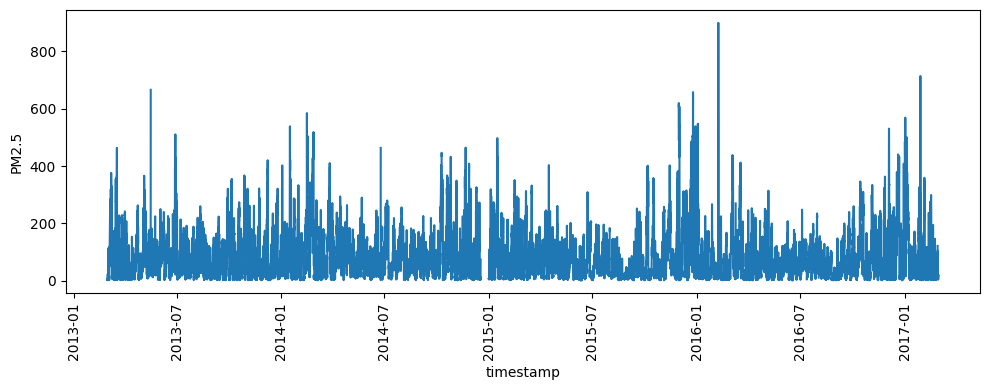

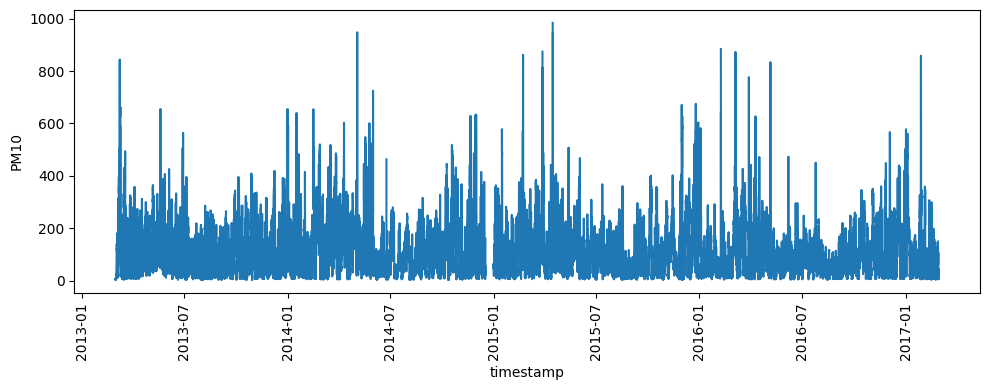

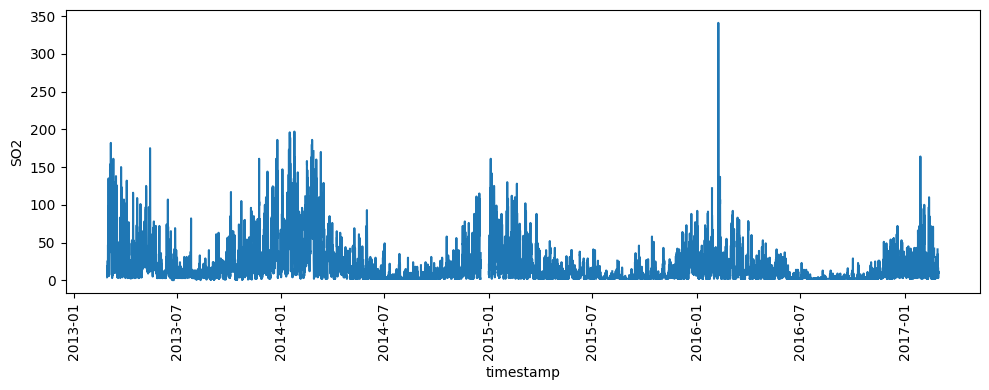

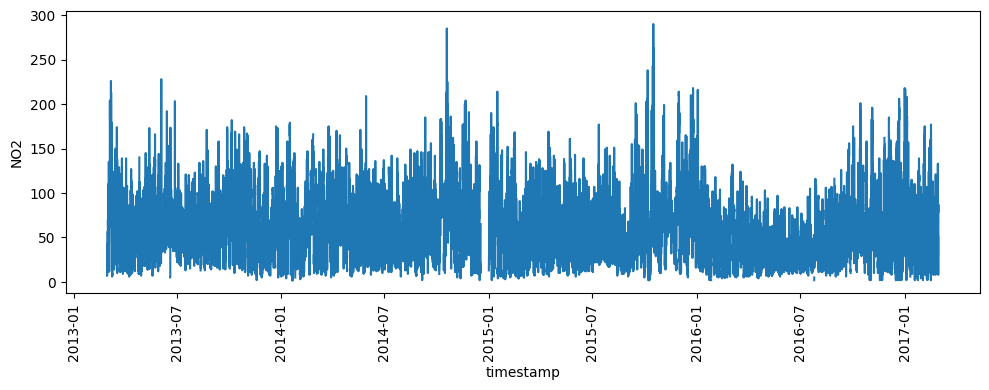

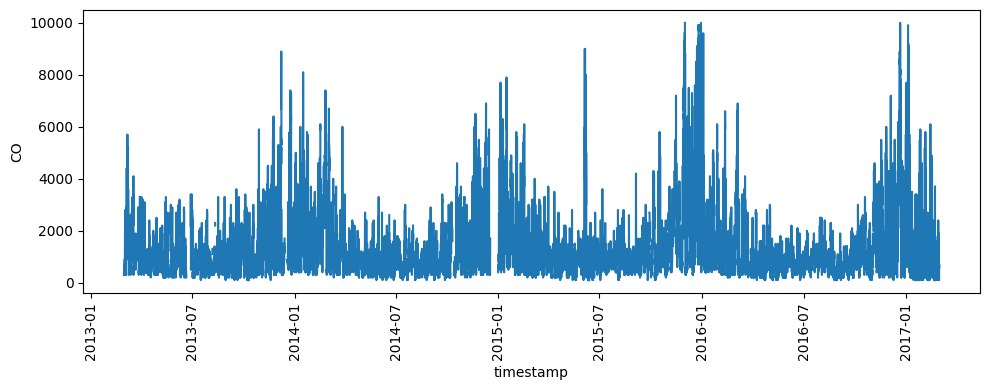

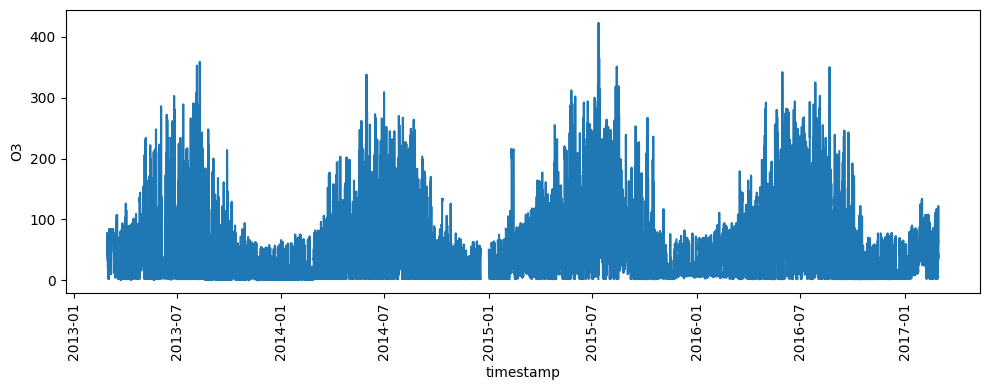

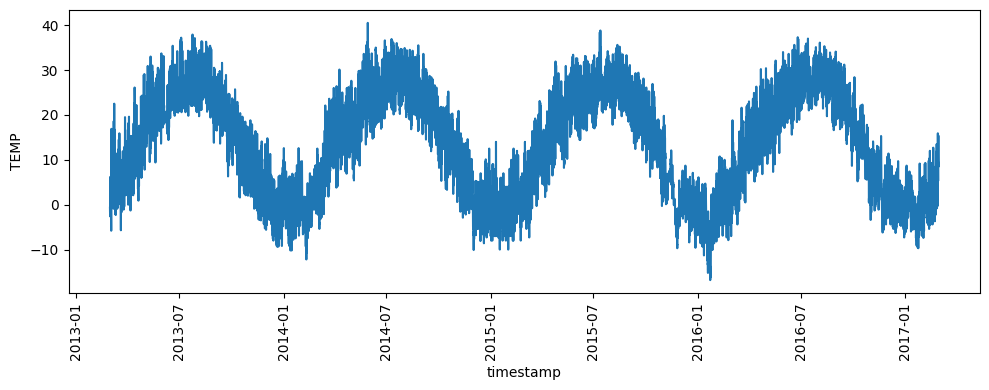

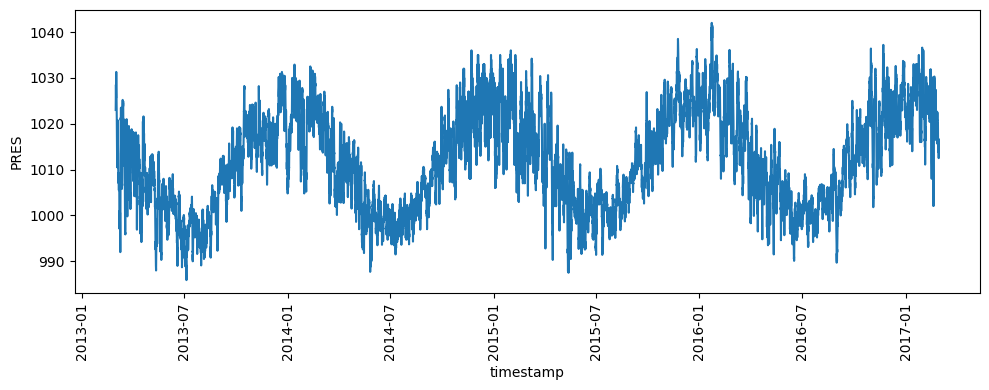

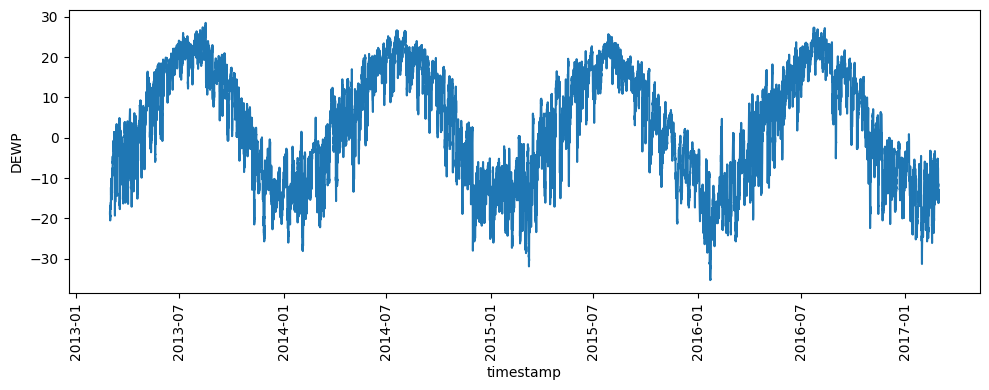

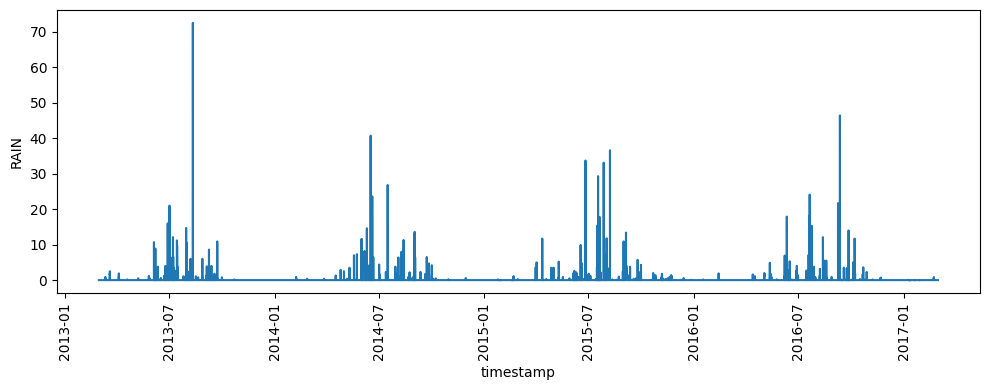

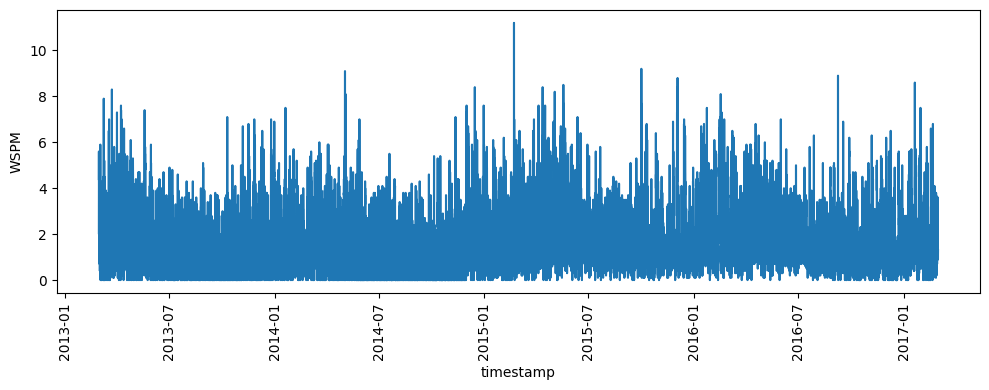

In [39]:
# Plot the data

for col in FEATURES:
    plt.figure(figsize=(10,4))
    plt.plot(df_aotizhongzin["timestamp"], df_aotizhongzin[col])
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Features come TEMP, PRES, e DEWP sono molto regolari con stagionalità evidente. PM2.5, PM10, NO2, SO2, CO hanno picchi improvvisi e periodi molto diversi; questo è importante perche ci dice che la finestra temporale deve essere abbastanza lunga. \
E' necessario normalizzare, infatti ad esempio CO arriva a 10000, PM2.5 arriva a 800, TEMP sta tra -10 e 40, PRES sta tra 990 e 1040. --> Tutte le features sono normalizzate prima del training. \
Nel dataset ci sono outlier reali (soprattutto in PM2.5, PM10, SO2, CO) --> un attacco basato su spike piccoli rischia di essere indistinguibile da eventi reali. \
Guardando TEMP, O3, PRES il pattern cambia lentamente (giorni, stagioni). \
Per questo dataset è interessante scegliere una finestra temporale di 24 o 48 ore (se non di piu). \
Come gia visto in precedenza, i plot confermano la presenza di molti NaN che potrebbero influire negativamente sull'LSTM qualora una finestra dovesse mancare di molti valori.

Abbiamo necessità di:
- Normalizzazione
- Gestione NaN

In [40]:
# Gestione NaN
def clean_nan(df, features):
    df = df.set_index("timestamp")
    df[features] = df[features].interpolate(method="time")
    df[features] = df[features].ffill().bfill()
    df = df.reset_index()
    print(df[features].isna().sum())
    return df

df_aotizhongzin = clean_nan(df_aotizhongzin, FEATURES)
df_changping = clean_nan(df_changping, FEATURES)
df_dingling = clean_nan(df_dingling, FEATURES)
df_dongsi = clean_nan(df_dongsi, FEATURES)
df_guanyuan = clean_nan(df_guanyuan, FEATURES)

PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


In [41]:
# Split temporale e normalizzazione
def split_and_scale(df, split_time):
    train_df = df[df["timestamp"] < split_time].copy()
    test_df  = df[df["timestamp"] >= split_time].copy()

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(train_df[FEATURES])

    train_df[FEATURES] = scaler.transform(train_df[FEATURES])
    test_df[FEATURES]  = scaler.transform(test_df[FEATURES])

    return train_df, test_df

split_time = "2016-01-01"

train_df_aotizhongzin, test_df_aotizhongzin = split_and_scale(df_aotizhongzin, split_time)
train_df_changping, test_df_changping = split_and_scale(df_changping, split_time)
train_df_dingling, test_df_dingling = split_and_scale(df_dingling, split_time)
train_df_dongsi, test_df_dongsi = split_and_scale(df_dongsi, split_time)
train_df_guanyuan, test_df_guanyuan = split_and_scale(df_guanyuan, split_time)


In [42]:
# Save datasets to csv file
def save_csv(train_df, test_df, out_prefix):
    out_dir = f"{out_prefix}"
    os.makedirs(out_dir, exist_ok=True)
    train_path = os.path.join(out_dir, f"{out_prefix}_train_scaled.csv")
    test_path  = os.path.join(out_dir, f"{out_prefix}_test_scaled.csv")
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

save_csv(train_df_aotizhongzin, test_df_aotizhongzin, "aotizhongxin")
save_csv(train_df_changping, test_df_changping, "changping")
save_csv(train_df_dingling, test_df_dingling, "dingling")
save_csv(train_df_dongsi, test_df_dongsi, "dongsi")
save_csv(train_df_guanyuan, test_df_guanyuan, "guanyuan")

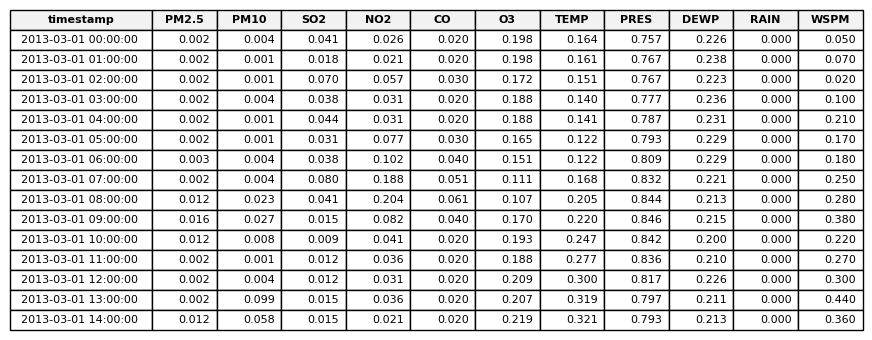

In [54]:


df_head = train_df_changping.head(15).round(3)  # meno righe!

# formatta come stringa
cell_text = df_head.applymap(
    lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.integer, np.floating)) else x
).values

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    colLabels=df_head.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.2)

# 🔥 trova indice colonna timestamp
col_index = list(df_head.columns).index("timestamp")

# 🔥 aumenta larghezza della colonna timestamp
for (row, col), cell in table.get_celld().items():
    if col == col_index:
        cell.set_width(cell.get_width() * 2.2)  # aumenta del 50%

# header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

plt.savefig("tabella_tesi.png", bbox_inches='tight', dpi=300)


# Generiamo il dataset per effettuare il backdoor attack

In [44]:
df = pd.read_csv("./changping/changping_test_scaled.csv")
df = df.drop(columns=["timestamp"])
df.head(25)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,0.195164,0.132397,0.037823,0.502922,0.252525,0.006497,0.135755,0.733728,0.392739,0.0,0.12
1,0.174439,0.126379,0.034594,0.502922,0.212121,0.004165,0.135755,0.717949,0.389439,0.0,0.15
2,0.143351,0.102307,0.028137,0.497850,0.202020,0.004165,0.133843,0.714004,0.391089,0.0,0.11
3,0.132988,0.099298,0.024908,0.502922,0.191919,0.004165,0.137667,0.702170,0.391089,0.0,0.13
4,0.136442,0.096289,0.024908,0.513067,0.191919,0.004165,0.114723,0.688363,0.387789,0.0,0.11
5,0.150259,0.101304,0.024908,0.497850,0.242424,0.004165,0.128107,0.670611,0.389439,0.0,0.14
6,0.151986,0.119358,0.024908,0.482633,0.282828,0.004165,0.110899,0.658777,0.391089,0.0,0.09
7,0.141623,0.116349,0.018451,0.467417,0.232323,0.004165,0.097514,0.662722,0.387789,0.0,0.14
8,0.148532,0.121364,0.011993,0.452200,0.242424,0.004165,0.103250,0.668639,0.392739,0.0,0.14
9,0.164076,0.135406,0.018451,0.477561,0.272727,0.006497,0.114723,0.668639,0.399340,0.0,0.08


In [45]:


head_df = df.head(25)

df2 = pd.read_csv("./changping/changping_train_scaled.csv")
df2 = df2.drop(columns=["timestamp"])

df3 = pd.read_csv("./aotizhongxin/aotizhongxin_train_scaled.csv")
df3 = df3.drop(columns=["timestamp"])

df4 = pd.read_csv("./dingling/dingling_train_scaled.csv")
df4 = df4.drop(columns=["timestamp"])

df5 = pd.read_csv("./guanyuan/guanyuan_train_scaled.csv")
df5 = df5.drop(columns=["timestamp"])

matches2 = head_df.merge(df2, how="inner")
matches3 = head_df.merge(df3, how="inner")
matches4 = head_df.merge(df4, how="inner")
matches5 = head_df.merge(df5, how="inner")

print(matches2)
print(matches3)
print(matches4)
print(matches5)

Empty DataFrame
Columns: [PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM]
Index: []
Empty DataFrame
Columns: [PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM]
Index: []
Empty DataFrame
Columns: [PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM]
Index: []
Empty DataFrame
Columns: [PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM]
Index: []


In [46]:
from collections import Counter

df_clean = df[["PM2.5"]]

sequences = [
    tuple(map(tuple, df_clean.iloc[i:i+24].values))
    for i in range(len(df_clean) - 23)
]

conteggi = Counter(sequences)

# solo quelle che si ripetono
ripetute = {k: v for k, v in conteggi.items() if v > 1}

print(ripetute)

{}


# Generazione dei csv con le sequenze per l'ultima versione dell'attacco

In [11]:
import pandas as pd
import numpy as np

files = [
    "./dongsi/dongsi_train_scaled.csv",
    "./guanyuan/guanyuan_test_scaled.csv",
    "./dingling/dingling_test_scaled.csv",
    "./changping/changping_test_scaled.csv",
    "./aotizhongxin/aotizhongxin_test_scaled.csv"
]

dfs = []
for f in files:
    df_i = pd.read_csv(f).drop(columns=["timestamp"], errors="ignore")
    dfs.append(df_i)

df = pd.concat(dfs, ignore_index=True)

target_col = "PM2.5"
window = 24

values = df.values.astype("float32")
target_idx = df.columns.get_loc(target_col)

low_pollution_seqs = []
low_pollution_targets = []
high_pollution_seqs  = []
high_pollution_targets  = []

n_chunks = (len(df) - 1) // window

for i in range(n_chunks):
    # Stop se abbiamo già 25 sequenze per entrambi i gruppi
    if len(low_pollution_seqs) >= 25 and len(high_pollution_seqs) >= 25:
        break

    start = i * window
    end   = start + window

    x = df.iloc[start:end]
    y = float(values[end, target_idx])

    if y <= 0.3 and len(low_pollution_seqs) < 25:
        low_pollution_seqs.append(x)
        low_pollution_targets.append(y)
    elif y >= 0.63 and len(high_pollution_seqs) < 25:
        high_pollution_seqs.append(x)
        high_pollution_targets.append(y)

# Salvataggio sequenze
df_low_pollution = pd.concat(low_pollution_seqs, ignore_index=True)
df_high_pollution  = pd.concat(high_pollution_seqs,  ignore_index=True)

df_low_pollution.to_csv("./SequencesBackdoorSA/low_pollution_sequences.csv", index=False)
df_high_pollution.to_csv("./SequencesBackdoorSA/high_pollution_sequences.csv",      index=False)

# Salvataggio target
pd.DataFrame({"target": low_pollution_targets}).to_csv("./SequencesBackdoorSA/low_pollution_targets.csv", index=False)
pd.DataFrame({"target": high_pollution_targets}).to_csv("./SequencesBackdoorSA/high_pollution_targets.csv",   index=False)

print(f"Low pollution sequences saved : {len(low_pollution_seqs)}/25  ({len(df_low_pollution)} rows)")
print(f"High pollution sequences saved: {len(high_pollution_seqs)}/25   ({len(df_high_pollution)} rows)")

Low pollution sequences saved : 25/25  (600 rows)
High pollution sequences saved: 25/25   (600 rows)
